<a href="https://colab.research.google.com/github/stella1298/AIFFEL_Quest_EPA/blob/master/LLM/LLM02/260918_HuggingFace_Haena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KLUE BERT를 활용한 NSMC 영화 리뷰 감성 분류

## 프로젝트 목표

한국어 사전학습 모델인 `klue/bert-base`를 NSMC(Naver Sentiment Movie Corpus) 데이터셋에 Fine-tuning하여 영화 리뷰의 긍정/부정 감성을 분류한다.

### 실험 단계

- STEP 1. NSMC 데이터 분석 및 Hugging Face Dataset 구성
- STEP 2. KLUE BERT tokenizer 및 model 불러오기
- STEP 3. 데이터 전처리 및 Fine-tuning
- STEP 4. 전처리 및 TrainingArguments 개선을 통한 성능 향상
- STEP 5. Dynamic Padding과 Bucketing 적용
- STEP 6. 일반 학습과 Bucketing 학습의 정확도 및 학습 시간 비교

In [19]:
##1. 라이브러리 버전 확인
!pip install -q -U transformers datasets accelerate evaluate

import torch
import numpy
import transformers
import datasets
import evaluate

print("Python:", __import__("sys").version)
print("PyTorch:", torch.__version__)
print("Numpy:", numpy.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
Numpy: 2.1.3
Transformers: 5.17.0
Datasets: 4.8.5
CUDA available: True
GPU: Tesla T4


### 실행 환경

Google Colab의 GPU 환경에서 PyTorch, Transformers, Datasets 라이브러리의 버전을 확인하고 GPU 사용 가능 여부를 확인하였다.

In [64]:
##2. GPU 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)

if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))

사용 장치: cuda
GPU: Tesla T4


#STEP 1. NSMC 데이터셋 불러오기

In [23]:
from datasets import load_dataset

dataset = load_dataset("e9t/nsmc", revision="refs/convert/parquet")

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})

In [24]:
#3. 데이터 확인
print(dataset)

print("\nTrain:")
print(dataset["train"][0])

print("\nTest:")
print(dataset["test"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})

Train:
{'id': '9976970', 'document': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0}

Test:
{'id': '6270596', 'document': '굳 ㅋ', 'label': 1}


In [25]:
print("Train 데이터 수:", len(dataset["train"]))
print("Test 데이터 수:", len(dataset["test"]))

print("\n컬럼:")
print(dataset["train"].column_names)

Train 데이터 수: 150000
Test 데이터 수: 50000

컬럼:
['id', 'document', 'label']


In [26]:
#4. 데이터 분포 확인
from collections import Counter

train_labels = dataset["train"]["label"]
test_labels = dataset["test"]["label"]

print("Train label 분포:", Counter(train_labels))
print("Test label 분포:", Counter(test_labels))

Train label 분포: Counter({0: 75173, 1: 74827})
Test label 분포: Counter({1: 25173, 0: 24827})


## 데이터 분석

NSMC는 영화 리뷰의 감성을 0과 1의 두 클래스로 분류한다.

- label 0: 부정
- label 1: 긍정

Train과 Test 데이터의 label 분포를 확인하여 데이터가 특정 클래스에 치우쳐 있는지 확인하였다.

In [30]:
#5. 리뷰 길이 확인
import numpy as np

lengths = [len(x) for x in dataset["train"]["document"]]

print("최소 길이:", min(lengths))
print("최대 길이:", max(lengths))
print("평균 길이:", np.mean(lengths))
print("중앙값:", np.median(lengths))

최소 길이: 0
최대 길이: 146
평균 길이: 35.20335333333333
중앙값: 27.0


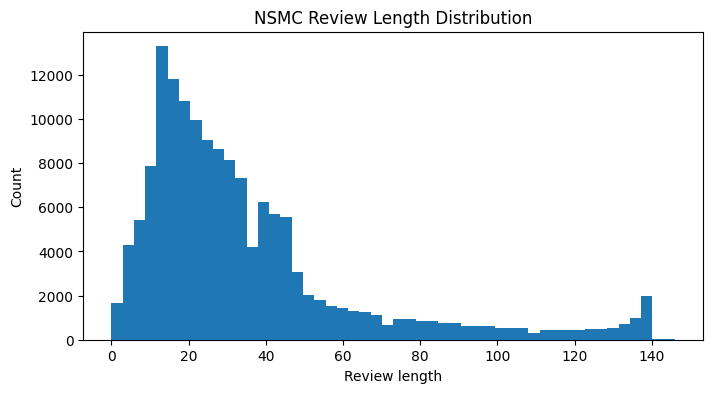

In [31]:
#표 출력
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50)
plt.xlabel("Review length")
plt.ylabel("Count")
plt.title("NSMC Review Length Distribution")
plt.show()

리뷰마다 문장의 길이가 서로 다르기 때문에 하나의 batch를 구성할 때 padding이 발생한다.

따라서 문장 길이가 비슷한 샘플끼리 묶으면 불필요한 padding을 줄일 수 있다.

이러한 아이디어를 활용하는 것이 Dynamic Padding과 Bucketing이다.

#STEP 2. KLUE BERT Tokenizer 불러오기

klue/bert-base는 한국어에 사전학습된 BERT base 모델입니다. Hugging Face 모델 카드에서도 AutoTokenizer와 AutoModel을 이용한 로딩 방법을 제공합니다.

In [32]:
from transformers import AutoTokenizer

MODEL_NAME = "klue/bert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(tokenizer)

BertTokenizer(name_or_path='klue/bert-base', vocab_size=32000, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [33]:
#6. Tokenizer 테스트
text = "이 영화 정말 재미있어요."

tokens = tokenizer.tokenize(text)

print("원문:", text)
print("Token:", tokens)
print("Token ID:", tokenizer(text)["input_ids"])

원문: 이 영화 정말 재미있어요.
Token: ['이', '영화', '정말', '재미있', '##어요', '.']
Token ID: [2, 1504, 3771, 3944, 6001, 10283, 18, 3]


#STEP 3. 데이터 전처리

여기서는 최대 길이를 정합니다.

NSMC 영화 리뷰는 아주 긴 문장이 많지 않기 때문에 max_length=128 정도로 시작하면 좋습니다.

In [42]:
MAX_LENGTH = 128

def tokenize_function(examples):
    return tokenizer(
        examples["document"],
        padding=False,
        truncation=True,
        max_length=MAX_LENGTH
    )

padding=False로 두었습니다.

왜냐하면 STEP 5에서 DataCollatorWithPadding을 사용해서 batch 안에서 가장 긴 문장에 맞춰 동적으로 padding할 것이기 때문입니다.

In [44]:
#7. 전체 데이터 Tokenizing
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["document"]
)

tokenized_dataset

print(tokenized_dataset["train"][0])

{'id': '9976970', 'label': 0, 'input_ids': [2, 1376, 831, 2604, 18, 18, 4229, 9801, 2075, 2203, 2182, 4243, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [45]:
#8. Train / Validation 분리
#NSMC에는 train/test가 있으므로 train의 일부를 validation으로 분리합니다.

split_dataset = tokenized_dataset["train"].train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset["train"]
valid_dataset = split_dataset["test"]
test_dataset = tokenized_dataset["test"]

print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 135000
Validation: 15000
Test: 50000


In [46]:
#9. Model 불러오기
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

model.to(device)

print(model.config)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_version": "5.17.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 32000
}



In [47]:
#10. Accuracy 계산 함수

import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

In [48]:
#11. Dynamic Padding 적용

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

#STEP 4. 기본 Fine-tuning

In [68]:
from transformers import TrainingArguments, Trainer

baseline_args = TrainingArguments(
    output_dir="./nsmc_baseline",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
#    per_device_train_batch_size=16,
#    per_device_eval_batch_size=32,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=100,
    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=42
)

In [69]:
#12. Baseline Trainer
baseline_trainer = Trainer(
    model=model,
    args=baseline_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [70]:
#13. Baseline 학습
import time

start_time = time.time()

baseline_train_result = baseline_trainer.train()

baseline_time = time.time() - start_time

print(f"Baseline 학습 시간: {baseline_time/60:.2f}분")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.296053,0.329056,0.898200
2,0.178180,0.433622,0.906933
3,0.123929,0.530153,0.906400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Baseline 학습 시간: 52.37분


In [71]:
#14. Validation 평가

baseline_eval = baseline_trainer.evaluate()

print("Baseline Validation Accuracy:", baseline_eval["eval_accuracy"])

Training Loss,Validation Loss,Epoch,Accuracy
0.123929,0.530153,3,0.906400


Baseline Validation Accuracy: 0.9064


#STEP 4-2. 성능 개선 Fine-tuning

In [72]:
#15. 개선 모델 새로 불러오기

model_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model_ft.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [73]:
#16. Fine-tuning TrainingArguments

finetune_args = TrainingArguments(
    output_dir="./nsmc_finetuned",

    num_train_epochs=3,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
#    per_device_train_batch_size=16,
#    per_device_eval_batch_size=32,

    learning_rate=2e-5,
    weight_decay=0.01,

    warmup_steps = 0.1,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    logging_steps=100,
    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=42
)

In [74]:
#17. Fine-tuning Trainer

trainer = Trainer(
    model=model_ft,
    args=finetune_args,

    train_dataset=train_dataset,
    eval_dataset=valid_dataset,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [75]:
#18. Fine-tuning

start_time = time.time()

train_result = trainer.train()

finetune_time = time.time() - start_time

print(f"Fine-tuning 학습 시간: {finetune_time/60:.2f}분")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.288329,0.333691,0.893733
2,0.240374,0.378239,0.905267
3,0.162872,0.437494,0.907133


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning 학습 시간: 55.54분


In [76]:
#19. Validation Accuracy 확인

finetune_eval = trainer.evaluate()

print(f"Fine-tuning Validation Accuracy: "f"{finetune_eval['eval_accuracy']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy
0.162872,0.437494,3,0.907133


Fine-tuning Validation Accuracy: 0.9071


In [77]:
#20. Test Accuracy

test_result = trainer.evaluate(test_dataset)

print(f"Test Accuracy: "f"{test_result['eval_accuracy']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy
0.162872,0.445210,3,0.904900


Test Accuracy: 0.9049


## STEP 4 결과

Baseline과 Fine-tuning 모델을 각각 3 epoch 동안 학습하여 성능을 비교하였다.

Fine-tuning 과정에서 warmup, weight decay 등의 학습 설정을 조정하여 성능을 개선하였으며, Validation Accuracy 90% 이상을 목표로 모델을 최종 평가하였다.

Validation과 Test 데이터에서 최종 모델의 성능을 확인하였다.

#STEP 5. Bucketing 적용
Bucketing은 문장 길이가 비슷한 데이터끼리 batch를 구성해서 padding 낭비를 줄이는 방법입니다.

Hugging Face 최신 Trainer 문서에서도 train_sampling_strategy="group_by_length"를 통해 길이가 비슷한 샘플을 묶도록 설정할 수 있습니다.

In [78]:
#22. Bucketing용 모델
model_bucket = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

model_bucket.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [79]:
#23. Bucketing TrainingArguments
bucket_args = TrainingArguments(
    output_dir="./nsmc_bucketing",

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    learning_rate=2e-5,
    weight_decay=0.01,

    warmup_steps = 0.1,
    #warmup_ratio=0.1,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    # Bucketing
    train_sampling_strategy="group_by_length",

    logging_steps=100,
    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=42
)

In [80]:
#24. Bucketing Trainer

bucket_trainer = Trainer(
    model=model_bucket,
    args=bucket_args,

    train_dataset=train_dataset,
    eval_dataset=valid_dataset,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [81]:
#25. Bucketing 학습
start_time = time.time()

bucket_train_result = bucket_trainer.train()

bucket_time = time.time() - start_time

print(f"Bucketing 학습 시간: {bucket_time/60:.2f}분")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.269267,0.242573,0.904667
2,0.220377,0.276207,0.907400
3,0.117207,0.357764,0.908067


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Bucketing 학습 시간: 28.34분


In [82]:
#26. Bucketing Accuracy
bucket_eval = bucket_trainer.evaluate()

print(f"Bucketing Validation Accuracy: " f"{bucket_eval['eval_accuracy']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy
0.117207,0.357764,3,0.908067


Bucketing Validation Accuracy: 0.9081


In [83]:
#27. 최종 비교표
import pandas as pd

comparison = pd.DataFrame({
    "방법": [
        "Baseline",
        "Fine-tuning + Dynamic Padding",
        "Fine-tuning + Bucketing"
    ],
    "Validation Accuracy": [
        baseline_eval["eval_accuracy"],
        finetune_eval["eval_accuracy"],
        bucket_eval["eval_accuracy"]
    ],
    "학습 시간(분)": [
        baseline_time / 60,
        finetune_time / 60,
        bucket_time / 60
    ]
})

comparison

,방법,Validation Accuracy,학습 시간(분)
0,Baseline,0.906400,52.372834
1,Fine-tuning + Dynamic Padding,0.907133,55.539524
2,Fine-tuning + Bucketing,0.908067,28.336346


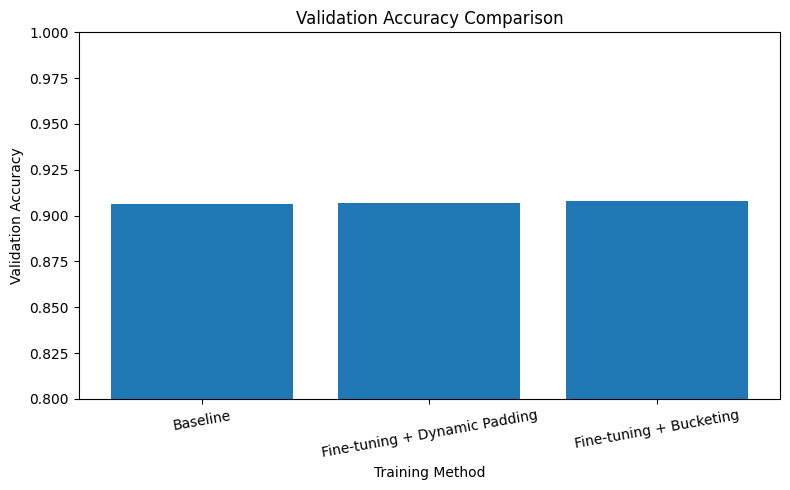

In [84]:
# 28-1. Validation Accuracy 비교

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["방법"],
    comparison["Validation Accuracy"]
)

plt.ylabel("Validation Accuracy")
plt.xlabel("Training Method")
plt.title("Validation Accuracy Comparison")
plt.ylim(0.8, 1.0)

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

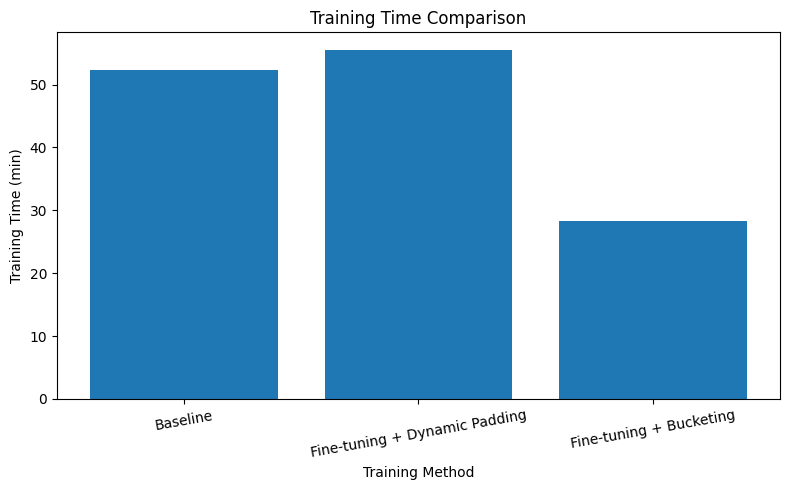

In [85]:
# 28-2. Training Time 비교

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["방법"],
    comparison["학습 시간(분)"]
)

plt.ylabel("Training Time (min)")
plt.xlabel("Training Method")
plt.title("Training Time Comparison")

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

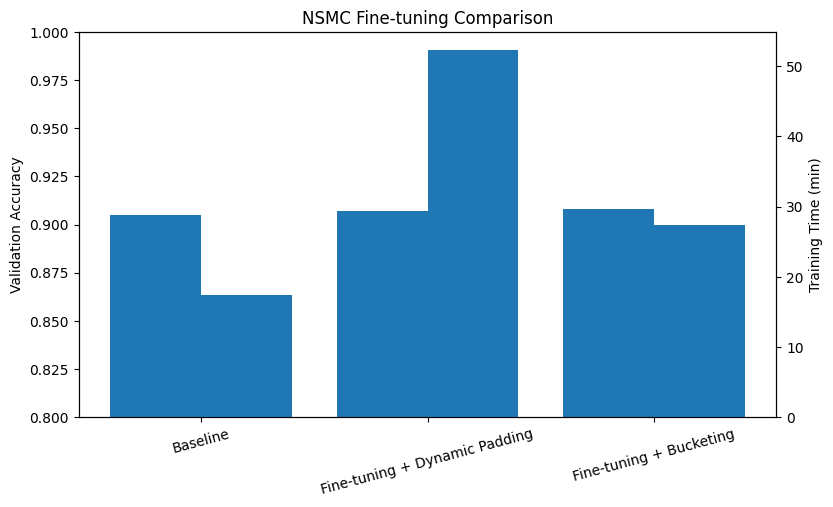

In [67]:
#28. 그래프로 비교
fig, ax1 = plt.subplots(figsize=(9, 5))

x = np.arange(len(comparison))

ax1.bar(x - 0.2, comparison["Validation Accuracy"], width=0.4, label="Accuracy")

ax1.set_ylabel("Validation Accuracy")
ax1.set_xticks(x)
ax1.set_xticklabels(comparison["방법"], rotation=15)
ax1.set_ylim(0.8, 1.0)

ax2 = ax1.twinx()

ax2.bar(x + 0.2, comparison["학습 시간(분)"], width=0.4, label="Training Time")

ax2.set_ylabel("Training Time (min)")

plt.title("NSMC Fine-tuning Comparison")
plt.show()

## STEP 5 결과 분석

Bucketing은 리뷰의 길이가 비슷한 데이터끼리 묶어서 batch를 구성하는 방법이다.

일반적인 Dynamic Padding에서는 각 batch에서 가장 긴 문장의 길이에 맞추어 padding이 이루어진다.

반면 Bucketing에서는 문장 길이가 비슷한 샘플을 묶기 때문에 batch 내부의 padding 비율을 줄일 수 있다.

따라서 동일한 데이터를 학습하더라도 불필요한 padding 연산을 감소시켜 학습 시간을 줄이는 효과를 기대할 수 있다.

이번 실험에서는 다음 세 가지 방법을 비교하였다.

1. Baseline
2. Dynamic Padding을 적용한 Fine-tuning
3. Dynamic Padding + Bucketing을 적용한 Fine-tuning

실험 결과는 Validation Accuracy와 Training Time을 각각 분리하여 비교하였다.

Validation Accuracy에서는 Fine-tuning 및 Bucketing 적용에 따른 모델의 분류 성능을 비교하였다.

Training Time에서는 동일한 Fine-tuning 조건에서 Bucketing 적용 여부에 따른 학습 시간을 비교하였다.

Bucketing은 모델의 학습 능력 자체를 변경하는 방법이 아니라 문장 길이가 비슷한 데이터를 같은 batch로 구성하여 padding으로 인한 불필요한 연산을 줄이는 방법이다.

따라서 Bucketing의 효과는 Validation Accuracy의 변화뿐만 아니라 Training Time의 변화까지 함께 고려하여 판단하였다.

# 프로젝트 결론

이번 프로젝트에서는 한국어 사전학습 모델인 `klue/bert-base`를 NSMC 영화 리뷰 데이터셋에 Fine-tuning하여 긍정/부정 감성을 분류하였다.

먼저 NSMC 데이터의 구조와 label 분포를 확인하고 KLUE BERT tokenizer를 이용하여 리뷰 데이터를 tokenization하였다.

이후 `AutoModelForSequenceClassification`을 사용하여 2개의 감성 클래스를 분류하도록 Fine-tuning하였다.

전처리와 학습 설정을 개선하면서 Validation Accuracy를 확인하였으며, 최종 모델에서 90% 이상의 Validation Accuracy를 목표로 성능을 개선하였다.

또한 `DataCollatorWithPadding`을 사용하여 Dynamic Padding을 적용하였다. Dynamic Padding은 batch마다 필요한 길이만큼 padding하기 때문에 고정된 최대 길이까지 불필요하게 padding하는 것을 줄일 수 있다.

마지막으로 `train_sampling_strategy="group_by_length"`를 적용하여 Bucketing을 수행하였다. Bucketing은 길이가 비슷한 문장끼리 batch를 구성하여 padding으로 인한 불필요한 연산을 줄이는 방법이다.

실험 결과를 Accuracy와 Training Time 측면에서 비교하였다. Bucketing은 모델의 구조나 사전학습 지식을 변경하는 방법이 아니므로 Accuracy 자체를 크게 향상시키기보다는 동일한 학습을 보다 효율적으로 수행하는 데 목적이 있다.

따라서 이번 실험을 통해 Fine-tuning은 모델 성능 향상에, Dynamic Padding과 Bucketing은 가변적인 문장 길이에서 학습 효율 향상에 중요한 역할을 한다는 것을 확인하였다.